# Tau &rarr; 3&mu; Production: Basic Visualizations

Quick-look plots for the ACTS/OpenDataDetector tau3mu production:

- Kinematic distributions of the 3 truth signal muons (pT, eta, phi)
- Reconstructed tau mass from the 3 muons (truth four-vectors)
- Geometric distribution of the signal muons' hits in the tracker/muon system

This notebook reads directly from the production `.tar` archives (no extraction needed) and
only needs a plain scientific-Python kernel (numpy/pandas/matplotlib) -- no ACTS environment
required.

A "signal" event here is defined, same as the rest of the analysis in this directory, as an
event with exactly 3 truth muons (`particle_type` = &plusmn;13) sharing the primary vertex
(`particle_id_pv == 1`) in `particles_simulated.csv`.


In [2]:
import glob
import io
import tarfile
import csv
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline


## Configuration

- `PROD_DIR`: directory containing the `odd_output_tau3mu_run_*.tar` files.
- `N_FILES`: how many tar files to read (`None` = all of them). Each file holds 2000 initial
  events; reading a handful of files is usually enough for a representative quick look, and
  reading all of them takes a while for a dataset this size.


In [3]:
PROD_DIR = "/depot/cms/users/schul105/ACTS/test/acts/Examples/Scripts/Python/production_tau3mu"   # or e.g. "production_tau3mu_biased_seed" for the old dataset
N_FILES = 20                      # set to None to read the full production

TAU_MASS_PDG = 1.77686  # GeV

# ACTS GeometryIdentifier bit layout: volume occupies the top 8 bits of the 64-bit id.
def volume_of(geometry_id):
    return (int(geometry_id) >> 56) & 0xFF

# Volume IDs confirmed (by direct hit-position z-sign cross-check) to be the muon system
# pieces added by the DD4hep/ODD muon integration; everything else is grouped as "other".
MUON_VOLUMES = {4: "muon endcap (-z)", 36: "muon barrel", 37: "muon endcap (+z)"}


## Data loading

For every event with exactly 3 truth muons at the primary vertex, collect:
- the 3 muons' truth four-vectors (from `particles_simulated.csv`)
- all hits belonging to those 3 muons (from `hits.csv`), tagged with their volume id

This mirrors the selection used in the rest of the production analysis.


In [4]:
def iter_signal_events(tar_path):
    t = tarfile.open(tar_path, mode="r:")
    members = t.getmembers()
    by_event = defaultdict(dict)
    for m in members:
        name = m.name.split("/")[-1]
        if name.endswith("-particles_simulated.csv"):
            by_event[name.split("-")[0]]["particles"] = m
        elif name.endswith("-hits.csv"):
            by_event[name.split("-")[0]]["hits"] = m

    for evt, d in by_event.items():
        if "particles" not in d:
            continue
        f = t.extractfile(d["particles"])
        reader = csv.DictReader(io.TextIOWrapper(f, encoding="utf-8"))
        muons = {}
        for row in reader:
            if abs(int(row["particle_type"])) == 13 and int(row["particle_id_pv"]) == 1:
                key = (row["particle_id_pv"], row["particle_id_sv"], row["particle_id_part"],
                       row["particle_id_gen"], row["particle_id_subpart"])
                muons[key] = {
                    "px": float(row["px"]), "py": float(row["py"]), "pz": float(row["pz"]),
                    "m": float(row["m"]),
                }
        if len(muons) != 3 or "hits" not in d:
            continue

        f2 = t.extractfile(d["hits"])
        reader2 = csv.DictReader(io.TextIOWrapper(f2, encoding="utf-8"))
        hits = []
        for row in reader2:
            key = (row["particle_id_pv"], row["particle_id_sv"], row["particle_id_part"],
                   row["particle_id_gen"], row["particle_id_subpart"])
            if key not in muons:
                continue
            hits.append({
                "volume": volume_of(row["geometry_id"]),
                "x": float(row["tx"]), "y": float(row["ty"]), "z": float(row["tz"]),
                "muon_key": key,
            })

        yield {"tar": tar_path, "event": evt, "muons": muons, "hits": hits}

    t.close()


In [5]:
files = sorted(glob.glob(f"{PROD_DIR}/odd_output_tau3mu_run_*.tar"))
if N_FILES is not None:
    files = files[:N_FILES]
print(f"Reading {len(files)} tar file(s) from {PROD_DIR}/")

muon_rows = []
event_rows = []
hit_rows = []

for i, path in enumerate(files):
    n_events_here = 0
    for ev in iter_signal_events(path):
        n_events_here += 1
        muons = ev["muons"]

        px = sum(m["px"] for m in muons.values())
        py = sum(m["py"] for m in muons.values())
        pz = sum(m["pz"] for m in muons.values())
        e = sum((m["px"]**2 + m["py"]**2 + m["pz"]**2 + m["m"]**2) ** 0.5 for m in muons.values())
        tau_mass = (max(e * e - px * px - py * py - pz * pz, 0.0)) ** 0.5
        event_rows.append({"tar": path, "event": ev["event"], "tau_mass": tau_mass})

        for key, m in muons.items():
            pt = (m["px"] ** 2 + m["py"] ** 2) ** 0.5
            p = (m["px"] ** 2 + m["py"] ** 2 + m["pz"] ** 2) ** 0.5
            eta = np.arctanh(m["pz"] / p) if p > 0 else 0.0
            phi = np.arctan2(m["py"], m["px"])
            muon_rows.append({"tar": path, "event": ev["event"], "pt": pt, "eta": eta,
                               "phi": phi, "pz": m["pz"]})

        for h in ev["hits"]:
            r = (h["x"] ** 2 + h["y"] ** 2) ** 0.5
            hit_rows.append({"tar": path, "event": ev["event"], "volume": h["volume"],
                              "x": h["x"], "y": h["y"], "z": h["z"], "r": r})

    print(f"[{i+1}/{len(files)}] {path.split('/')[-1]}: {n_events_here} signal events "
          f"(running total: {len(event_rows)})")

muons_df = pd.DataFrame(muon_rows)
events_df = pd.DataFrame(event_rows)
hits_df = pd.DataFrame(hit_rows)

print(f"\nTotal signal events: {len(events_df)}, signal muons: {len(muons_df)}, "
      f"hits from signal muons: {len(hits_df)}")


Reading 20 tar file(s) from /depot/cms/users/schul105/ACTS/test/acts/Examples/Scripts/Python/production_tau3mu/
[1/20] odd_output_tau3mu_run_0.tar: 21 signal events (running total: 21)
[2/20] odd_output_tau3mu_run_1.tar: 18 signal events (running total: 39)
[3/20] odd_output_tau3mu_run_2.tar: 18 signal events (running total: 57)
[4/20] odd_output_tau3mu_run_25.tar: 21 signal events (running total: 78)
[5/20] odd_output_tau3mu_run_26.tar: 30 signal events (running total: 108)
[6/20] odd_output_tau3mu_run_27.tar: 20 signal events (running total: 128)
[7/20] odd_output_tau3mu_run_28.tar: 20 signal events (running total: 148)
[8/20] odd_output_tau3mu_run_29.tar: 21 signal events (running total: 169)
[9/20] odd_output_tau3mu_run_30.tar: 19 signal events (running total: 188)
[10/20] odd_output_tau3mu_run_31.tar: 19 signal events (running total: 207)
[11/20] odd_output_tau3mu_run_32.tar: 17 signal events (running total: 224)
[12/20] odd_output_tau3mu_run_33.tar: 18 signal events (running tota

## Muon kinematic distributions

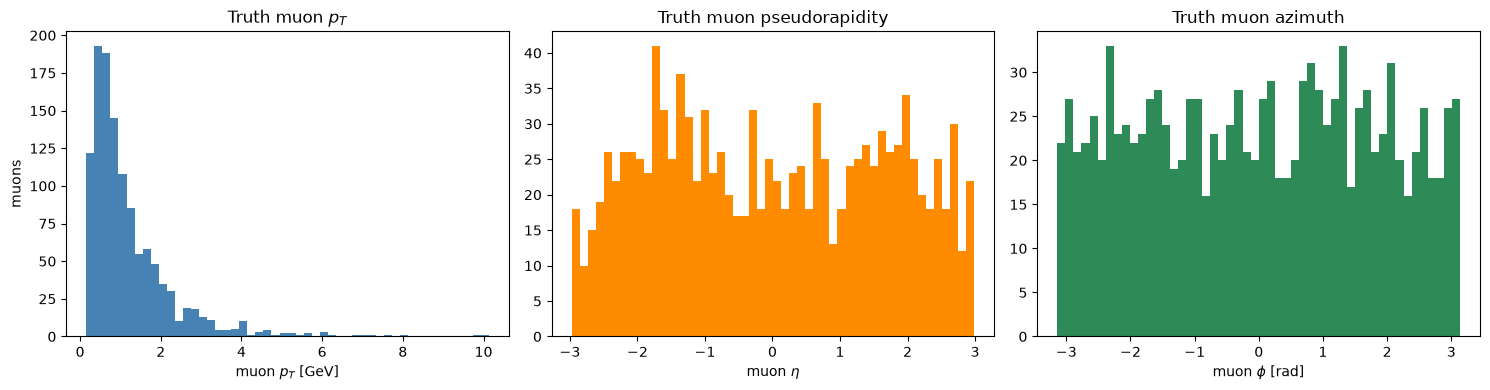

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(muons_df["pt"], bins=50, color="steelblue")
axes[0].set_xlabel("muon $p_T$ [GeV]")
axes[0].set_ylabel("muons")
axes[0].set_title("Truth muon $p_T$")

axes[1].hist(muons_df["eta"], bins=50, color="darkorange")
axes[1].set_xlabel(r"muon $\eta$")
axes[1].set_title("Truth muon pseudorapidity")

axes[2].hist(muons_df["phi"], bins=50, color="seagreen")
axes[2].set_xlabel(r"muon $\phi$ [rad]")
axes[2].set_title("Truth muon azimuth")

plt.tight_layout()
plt.show()


## Tau mass from the 3 muons

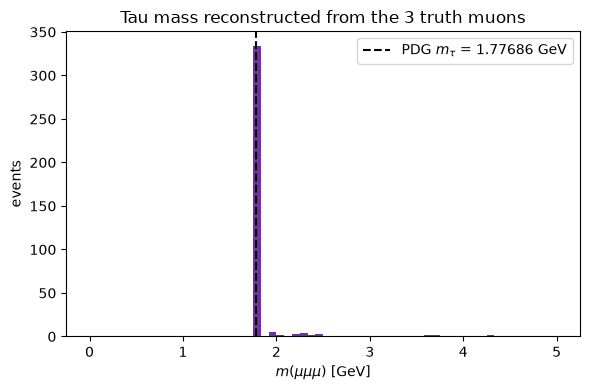

333/396 events match the PDG tau mass to <1 MeV (84.1%)


In [7]:
plt.figure(figsize=(6, 4))
plt.hist(events_df["tau_mass"], bins=60, range=(0, 5), color="indigo", alpha=0.8)
plt.axvline(TAU_MASS_PDG, color="black", linestyle="--", label=f"PDG $m_\\tau$ = {TAU_MASS_PDG} GeV")
plt.xlabel(r"$m(\mu\mu\mu)$ [GeV]")
plt.ylabel("events")
plt.title("Tau mass reconstructed from the 3 truth muons")
plt.legend()
plt.tight_layout()
plt.show()

n_match = (events_df["tau_mass"].sub(TAU_MASS_PDG).abs() < 0.001).sum()
print(f"{n_match}/{len(events_df)} events match the PDG tau mass to <1 MeV "
      f"({100*n_match/len(events_df):.1f}%)")


## Geometric distribution of the signal muons' hits

`r-z` is the standard detector hit map (radial distance from the beam axis vs. position along
the beam axis); `x-y` is the transverse view. Muon-system hits (volumes 4/36/37) are highlighted;
everything else is inner-tracker hits from the same 3 muons, grouped together as "other".


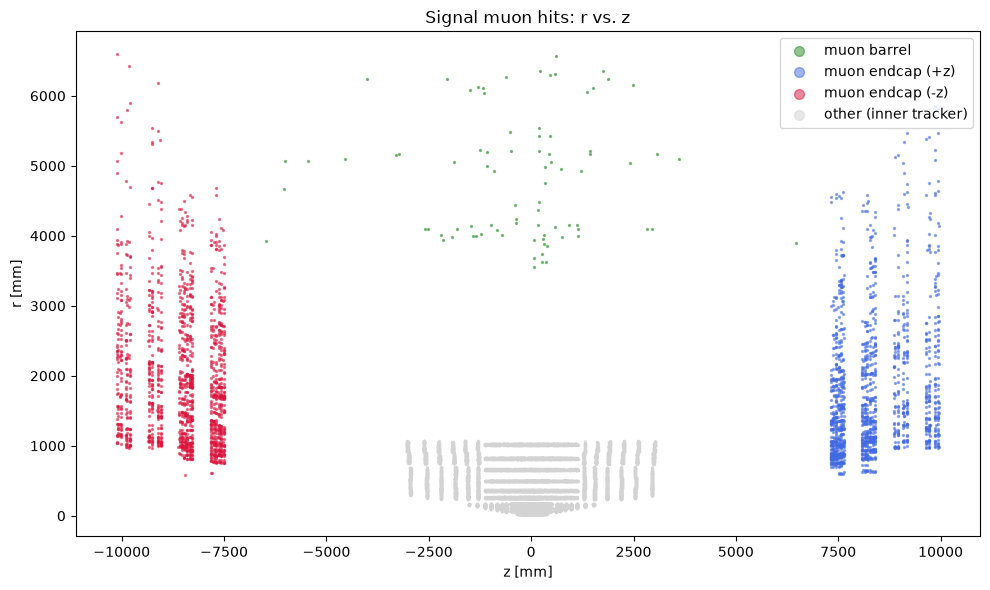

In [8]:
hits_df["region"] = hits_df["volume"].map(MUON_VOLUMES).fillna("other (inner tracker)")

fig, ax = plt.subplots(figsize=(10, 6))
colors = {"other (inner tracker)": "lightgray", "muon endcap (-z)": "crimson",
          "muon barrel": "forestgreen", "muon endcap (+z)": "royalblue"}
for region, grp in hits_df.groupby("region"):
    ax.scatter(grp["z"], grp["r"], s=2, alpha=0.5, label=region, color=colors.get(region))
ax.set_xlabel("z [mm]")
ax.set_ylabel("r [mm]")
ax.set_title("Signal muon hits: r vs. z")
ax.legend(markerscale=5, loc="upper right")
plt.tight_layout()
plt.show()


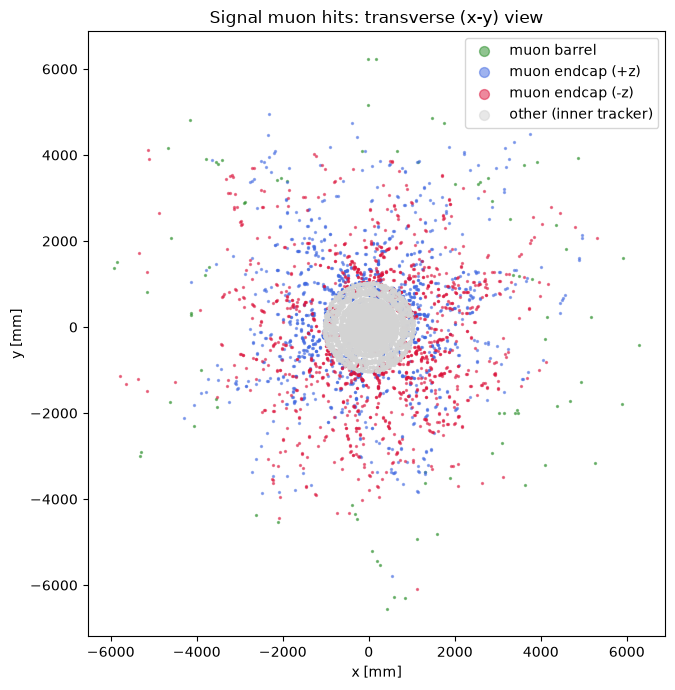

In [9]:
fig, ax = plt.subplots(figsize=(7, 7))
for region, grp in hits_df.groupby("region"):
    ax.scatter(grp["x"], grp["y"], s=2, alpha=0.5, label=region, color=colors.get(region))
ax.set_xlabel("x [mm]")
ax.set_ylabel("y [mm]")
ax.set_title("Signal muon hits: transverse (x-y) view")
ax.set_aspect("equal")
ax.legend(markerscale=5, loc="upper right")
plt.tight_layout()
plt.show()


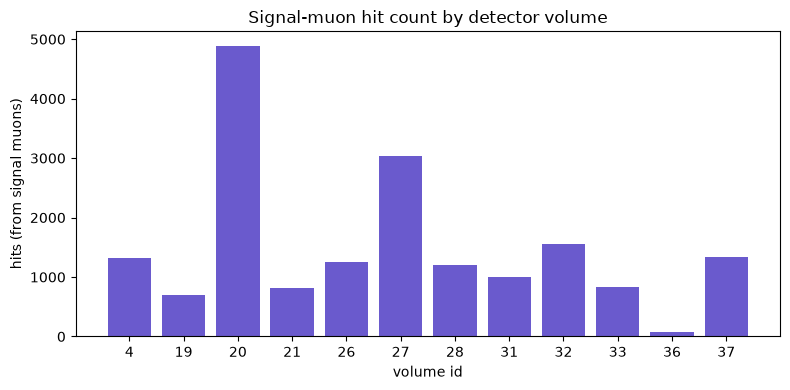

volume
4     1325
19     692
20    4888
21     824
26    1249
27    3038
28    1210
31     999
32    1560
33     831
36      83
37    1343
Name: count, dtype: int64


In [10]:
counts = hits_df["volume"].value_counts().sort_index()
plt.figure(figsize=(8, 4))
plt.bar(counts.index.astype(str), counts.values, color="slateblue")
plt.xlabel("volume id")
plt.ylabel("hits (from signal muons)")
plt.title("Signal-muon hit count by detector volume")
plt.tight_layout()
plt.show()

print(counts)


## Summary

In [11]:
n_muons_with_hit = hits_df["muon_key" if "muon_key" in hits_df else "event"].nunique()
print(f"Tar files read:        {len(files)}")
print(f"Signal events:         {len(events_df)}")
print(f"Signal muons:          {len(muons_df)}")
print(f"Signal-muon pT:        mean={muons_df['pt'].mean():.3f} GeV, "
      f"min={muons_df['pt'].min():.3f}, max={muons_df['pt'].max():.3f}")
print(f"Signal-muon |eta|:     mean={muons_df['eta'].abs().mean():.3f}")
print(f"Tau mass:              mean={events_df['tau_mass'].mean():.4f} GeV, "
      f"min={events_df['tau_mass'].min():.4f}, max={events_df['tau_mass'].max():.4f}")
print(f"Hits from signal muons: {len(hits_df)} across {hits_df['volume'].nunique()} volumes")


Tar files read:        20
Signal events:         396
Signal muons:          1188
Signal-muon pT:        mean=1.211 GeV, min=0.154, max=10.131
Signal-muon |eta|:     mean=1.469
Tau mass:              mean=2.2539 GeV, min=0.9119, max=28.7029
Hits from signal muons: 18042 across 12 volumes
